In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from imblearn.under_sampling import RandomUnderSampler  # Use UnderSampling instead of OverSampling
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns


In [6]:
# Load the data
df = pd.read_csv("../../Dataset/merged4new.csv")

# Strip any extra whitespace from column names
df.columns = df.columns.str.strip()

# Check if 'QuoteStatus' column exists
if 'QuoteStatus' not in df.columns:
    raise KeyError("Column 'QuoteStatus' not found in the dataset. Available columns: ", df.columns)

/var/folders/mp/py4ff1r97335nwgzfbn_c_bh0000gn/T/ipykernel_22078/2216906673.py:2: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../../Dataset/merged4new.csv")


In [7]:
# Step 1: Check the class distribution before encoding
print("Class distribution before encoding:")
print(df['QuoteStatus'].value_counts())

# Encode the 'QuoteStatus' column (Won = 1, Lost = 0)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(df['QuoteStatus'])

# Check the encoded classes
print("Encoded classes:", label_encoder.classes_)

Class distribution before encoding:
QuoteStatus
Won        1214881
Lost        546696
Revised     493241
Name: count, dtype: int64
Encoded classes: ['Lost' 'Revised' 'Won']



Class distribution before resampling:
[ 546696  493241 1214881]


/Users/roshit/Library/Python/3.9/lib/python/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/roshit/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/roshit/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(



Class distribution after downsampling:
[493241 493241 493241]

Model Accuracy: 0.5678048285999088

Classification Report:
               precision    recall  f1-score   support

        Lost       0.62      0.76      0.68     97930
     Revised       0.45      0.30      0.36     98757
         Won       0.58      0.65      0.61     99258

    accuracy                           0.57    295945
   macro avg       0.55      0.57      0.55    295945
weighted avg       0.55      0.57      0.55    295945


Confusion Matrix:
 [[74623 14744  8563]
 [32329 29307 37121]
 [13728 21421 64109]]


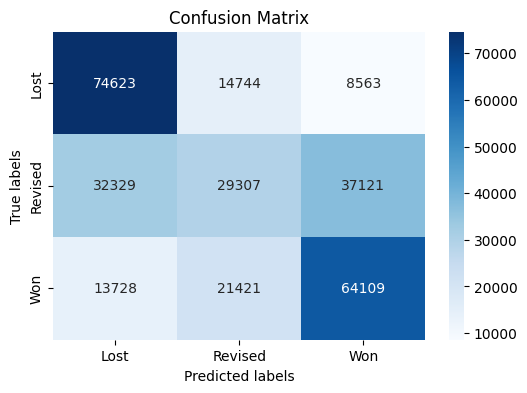

In [8]:

# Step 2: Check class distribution before resampling
print("\nClass distribution before resampling:")
print(np.bincount(y_encoded))  

if len(np.unique(y_encoded)) == 1:
    print("Only one class present. Model training is not possible.")
else:
    # Feature selection
    features = ['SalesPersonID', 'CustomerID', 'ProductGroupID', 'QuoteQty', 'UnitPrice']
    X = df[features]

    # Encode categorical features
    X_encoded = X.copy()
    categorical_columns = ['SalesPersonID', 'CustomerID', 'ProductGroupID']
    for col in categorical_columns:
        X_encoded[col] = LabelEncoder().fit_transform(X_encoded[col])

    # Handle missing values in the features using SimpleImputer
    imputer = SimpleImputer(strategy='mean')  
    X_imputed = imputer.fit_transform(X_encoded)

    # Scale numerical features (QuoteQty, UnitPrice) for better performance
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_imputed)

    # Apply RandomUnderSampler to balance the dataset and reduce training time
    undersampler = RandomUnderSampler(random_state=42)
    X_resampled, y_resampled = undersampler.fit_resample(X_scaled, y_encoded)

    # Step 3: Check the new class distribution after downsampling
    print("\nClass distribution after downsampling:")
    print(np.bincount(y_resampled))

    # Step 4: Split data into training and test sets
    X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

    # Initialize the GradientBoostingClassifier
    model = GradientBoostingClassifier(random_state=42)

    # Train the model
    model.fit(X_train, y_train)

    # Step 5: Make predictions
    y_pred = model.predict(X_test)

    # Step 6: Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    print("\nModel Accuracy:", accuracy)
    print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=label_encoder.classes_))

    # Confusion Matrix
    conf_matrix = confusion_matrix(y_test, y_pred)
    print('\nConfusion Matrix:\n', conf_matrix)

    # Step 7: Plot the confusion matrix
    plt.figure(figsize=(6, 4))
    sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='g', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
    plt.xlabel('Predicted labels')
    plt.ylabel('True labels')
    plt.title('Confusion Matrix')
    plt.show()